In [24]:
# Fase 1: Exploración y limpieza de datos

In [25]:
import pandas as pd
import numpy as np

# Mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)


df = pd.read_csv('datos_salud_habitos.csv')

In [26]:
## 1. Exploración inicial (EDA)

In [27]:
def eda_basico(df):
    print("🔍 Primeras filas del DataFrame:")
    display(df.head())

    print("🔍 Últimas filas del DataFrame:")
    display(df.tail())

    print("📌 Filas Aleatorias:")
    display(df.sample(n=5))

    print("📐 Dimensiones:")
    print(f"{df.shape[0]} filas y {df.shape[1]} columnas\n")


    print("📊 Tipos de datos por columna:")
    display(df.dtypes.rename("Tipo").to_frame())

    print("📉 Descripción de columnas numéricas:")
    display(df.describe().T)

    print("🔤 Descripción de columnas categóricas:")
    display(df.describe(include=["O"]))

    print("🚫 Valores nulos por columna:")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if len(nulos) > 0:
        display(pd.DataFrame({
            "Nulos": nulos,
            "Porcentaje (%)": (nulos / len(df) * 100).round(2)
        }))
    else:
        print("No hay valores nulos.\n")

    print("🗑️ Columnas constantes:")
    constantes = [col for col in df.columns if df[col].nunique() == 1]
    if constantes:
        display(pd.DataFrame({
            "Columna": constantes,
            "Valor único": [df[col].unique()[0] for col in constantes],
            "Acción": ["Eliminar en Fase 2"] * len(constantes)
        }))
    else:
        print("No hay columnas constantes.\n")

    print("📎 Filas duplicadas:")
    dup_count = df.duplicated().sum()

    if dup_count > 0:
        print(f"Duplicadas: {dup_count}")
        print("Ejemplo de duplicados:")
        display(df[df.duplicated()].head())
    else:
        print("No hay filas duplicadas.\n")

In [28]:
# 2. Limpieza de datos. Imputación de valores nulos

In [29]:
eda_basico(df)

🔍 Primeras filas del DataFrame:


,ID,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica
0,1.0,56.0,Femenino,37.10,Alto,Nunca,No,157.0,82.0,Muy Alto,110.3,NaN,NaN,8.0,NaN
1,2.0,69.0,Femenino,22.53,Moderado,Ocasional,No,167.0,69.0,Muy Alto,81.2,NaN,NaN,9.0,No
2,3.0,46.0,Femenino,20.46,Bajo,Frecuente,NaN,167.0,NaN,Normal,81.8,9.8,6079.0,NaN,No
3,4.0,32.0,Otro,23.93,Moderado,Nunca,No,105.0,111.0,Alto,190.0,8.2,15341.0,8.0,Sí
4,NaN,60.0,Femenino,19.26,Bajo,Frecuente,No,160.0,84.0,NaN,159.6,4.4,10981.0,6.0,No


🔍 Últimas filas del DataFrame:


,ID,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica
1195,1196.0,78.0,Masculino,18.00,NaN,Ocasional,No,155.0,68.0,Muy Alto,112.8,8.8,8240.0,8.0,Sí
1196,1197.0,69.0,Masculino,29.24,Alto,Nunca,NaN,114.0,115.0,Normal,146.4,9.4,5942.0,1.0,Sí
1197,1198.0,32.0,Masculino,NaN,Bajo,Ocasional,No,162.0,82.0,Muy Alto,180.1,7.7,14536.0,5.0,No
1198,1199.0,64.0,Masculino,24.08,Alto,Nunca,No,116.0,94.0,Muy Alto,NaN,4.0,2600.0,NaN,No
1199,1200.0,73.0,NaN,33.55,Alto,Frecuente,NaN,NaN,NaN,Alto,72.3,5.1,6700.0,4.0,No


📌 Filas Aleatorias:


...

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19744\3268321633.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["O"]))


,Genero,Nivel_Actividad,Consumo_Alcohol,Fumador,Colesterol,Enfermedad_Cronica
count,1080,1080,1080,1080,1080,1080
unique,3,3,3,2,3,2
top,Masculino,Bajo,Frecuente,Sí,Normal,Sí
freq,365,383,387,562,381,543


🚫 Valores nulos por columna:


,Nulos,Porcentaje (%)
ID,120,10.0
Edad,120,10.0
Genero,120,10.0
IMC,120,10.0
Nivel_Actividad,120,10.0
Consumo_Alcohol,120,10.0
Fumador,120,10.0
Presion_Sistolica,120,10.0
Presion_Diastolica,120,10.0
Colesterol,120,10.0


🗑️ Columnas constantes:
No hay columnas constantes.

📎 Filas duplicadas:
No hay filas duplicadas.



In [30]:
#Nulos en columnas categóricas

cat_cols = ["Genero", "Nivel_Actividad", "Consumo_Alcohol",
            "Fumador", "Colesterol", "Enfermedad_Cronica"]

for col in cat_cols:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

In [31]:
# Nulos en columnas numéricas -> MEDIANA POR GRUPO

# Paso 1: Edad con mediana global (es la base para crear los grupos)
df["Edad"] = df["Edad"].fillna(df["Edad"].median())

# Paso 2: crear rangos de edad
df["Rango_Edad"] = pd.cut(
    df["Edad"],
    bins=[17, 30, 45, 60, 80],
    labels=["18-30", "31-45", "46-60", "61-79"]
)

# Paso 3: función para imputar por grupo (con red de seguridad)
def imputar_por_grupo(df, columna, grupo):
    mediana_global = df[columna].median()
    df[columna] = df.groupby(grupo, observed=True)[columna] \
                     .transform(lambda x: x.fillna(x.median()))
    df[columna] = df[columna].fillna(mediana_global)
    return df[columna]

print("Nulos ANTES de imputar:\n", df.isnull().sum())

# Paso 4: aplicar mediana por grupo
# Variables fisiológicas -> agrupadas por rango de edad
for col in ["IMC", "Presion_Sistolica", "Presion_Diastolica", "Glucosa"]:
    df[col] = imputar_por_grupo(df, col, "Rango_Edad")

# Pasos diarios -> agrupado por nivel de actividad física
df["Pasos_Diarios"] = imputar_por_grupo(df, "Pasos_Diarios", "Nivel_Actividad")

# Sin variable de agrupación clara -> mediana global
for col in ["Horas_Sueno", "Satisfaccion_Vida"]:
    df[col] = df[col].fillna(df[col].median())

print("\nNulos DESPUÉS de imputar:\n", df.isnull().sum())

Nulos ANTES de imputar:
 ID                    120
Edad                    0
Genero                  0
IMC                   120
Nivel_Actividad         0
Consumo_Alcohol         0
Fumador                 0
Presion_Sistolica     120
Presion_Diastolica    120
Colesterol              0
Glucosa               120
Horas_Sueno           120
Pasos_Diarios         120
Satisfaccion_Vida     120
Enfermedad_Cronica      0
Rango_Edad              0
dtype: int64

Nulos DESPUÉS de imputar:
 ID                    120
Edad                    0
Genero                  0
IMC                     0
Nivel_Actividad         0
Consumo_Alcohol         0
Fumador                 0
Presion_Sistolica       0
Presion_Diastolica      0
Colesterol              0
Glucosa                 0
Horas_Sueno             0
Pasos_Diarios           0
Satisfaccion_Vida       0
Enfermedad_Cronica      0
Rango_Edad              0
dtype: int64


In [32]:
df.head(30)

,ID,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica,Rango_Edad
0,1.0,56.0,Femenino,37.100,Alto,Nunca,No,157.0,82.0,Muy Alto,110.30,7.0,10709.0,8.0,Sí,46-60
1,2.0,69.0,Femenino,22.530,Moderado,Ocasional,No,167.0,69.0,Muy Alto,81.20,7.0,9949.0,9.0,No,61-79
2,3.0,46.0,Femenino,20.460,Bajo,Frecuente,Sí,167.0,90.0,Normal,81.80,9.8,6079.0,5.0,No,46-60
3,4.0,32.0,Otro,23.930,Moderado,Nunca,No,105.0,111.0,Alto,190.00,8.2,15341.0,8.0,Sí,31-45
4,NaN,60.0,Femenino,19.260,Bajo,Frecuente,No,160.0,84.0,Normal,159.60,4.4,10981.0,6.0,No,46-60
5,6.0,25.0,Masculino,29.690,Bajo,Frecuente,Sí,108.0,113.0,Normal,128.10,5.1,4524.0,6.0,Sí,18-30
6,7.0,78.0,Masculino,38.610,Bajo,Frecuente,No,91.0,62.0,Muy Alto,116.40,8.6,9998.0,4.0,No,61-79
7,NaN,38.0,Femenino,18.870,Bajo,Frecuente,Sí,99.0,65.0,Alto,147.00,9.0,14697.0,5.0,Sí,31-45
8,9.0,56.0,Femenino,20.690,Bajo,Nunca,Sí,139.0,117.0,Muy Alto,128.40,7.7,14606.0,2.0,Sí,46-60
9,10.0,75.0,Otro,27.950,Bajo,Nunca,Sí,170.0,65.0,Alto,137.65,7.0,14429.0,3.0,Sí,61-79


In [33]:
# Renumerar la columna ID de 1 a N, sin huecos, todas las filas
df = df.reset_index(drop=True)
df["ID"] = df.index + 1
df["ID"] = df["ID"].astype(int)

# Comprobación
print("Nulos en ID:", df["ID"].isnull().sum())
print("IDs únicos:", df["ID"].nunique(), "de", len(df), "filas")

Nulos en ID: 0
IDs únicos: 1200 de 1200 filas


In [34]:
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in num_cols:

    valores = df[col].dropna()
    entero = (valores % 1 == 0).all()

    if entero:
        df[col] = df[col].astype(int)
        print(f"{col}: convertida a entero")
    else:
        print(f"{col}: decimales (tiene valores reales)")


df.dtypes

ID: convertida a entero
Edad: convertida a entero
IMC: decimales (tiene valores reales)
Presion_Sistolica: convertida a entero
Presion_Diastolica: convertida a entero
Glucosa: decimales (tiene valores reales)
Horas_Sueno: decimales (tiene valores reales)
Pasos_Diarios: convertida a entero
Satisfaccion_Vida: convertida a entero


ID                       int64
Edad                     int64
Genero                     str
IMC                    float64
Nivel_Actividad            str
Consumo_Alcohol            str
Fumador                    str
Presion_Sistolica        int64
Presion_Diastolica       int64
Colesterol                 str
Glucosa                float64
Horas_Sueno            float64
Pasos_Diarios            int64
Satisfaccion_Vida        int64
Enfermedad_Cronica         str
Rango_Edad            category
dtype: object

In [35]:
df.columns = df.columns.str.lower()

In [36]:
# Corregir la coherencia lógica: la presión sistólica siempre debe ser mayor que la diastólica (regla médica básica).


# Paso 1: detectar las filas donde esto NO se cumple
inconsistentes = df[df["presion_sistolica"] <= df["presion_diastolica"]]
print("Filas con presión inconsistente:", len(inconsistentes))

# Se observa que los valores simplemente están intercambiados
idx = inconsistentes.index
df.loc[idx, ["presion_sistolica", "presion_diastolica"]] = \
    df.loc[idx, ["presion_diastolica", "presion_sistolica"]].values

# Residuales
empates = df[df["presion_sistolica"] <= df["presion_diastolica"]].index
df.loc[empates, "presion_sistolica"] = df.loc[empates, "presion_diastolica"] + 1

print("Inconsistencias restantes:",
      (df["presion_sistolica"] <= df["presion_diastolica"]).sum())

Filas con presión inconsistente: 81
Inconsistencias restantes: 0


In [37]:
df = df.drop(columns=["rango_edad"])

In [38]:
#exportamos el csv limpio
df1 = df.copy()
df1.to_csv("dataset_limpio_salud.csv", index=False)

In [39]:
# Verificación final: el dataset limpio no debe tener nulos
print("Nulos por columna en el dataset limpio:")
print(df.isnull().sum())
print("\nTotal de nulos:", df.isnull().sum().sum())
print("Tipos de datos:\n", df.dtypes)

Nulos por columna en el dataset limpio:
id                    0
edad                  0
genero                0
imc                   0
nivel_actividad       0
consumo_alcohol       0
fumador               0
presion_sistolica     0
presion_diastolica    0
colesterol            0
glucosa               0
horas_sueno           0
pasos_diarios         0
satisfaccion_vida     0
enfermedad_cronica    0
dtype: int64

Total de nulos: 0
Tipos de datos:
 id                      int64
edad                    int64
genero                    str
imc                   float64
nivel_actividad           str
consumo_alcohol           str
fumador                   str
presion_sistolica       int64
presion_diastolica      int64
colesterol                str
glucosa               float64
horas_sueno           float64
pasos_diarios           int64
satisfaccion_vida       int64
enfermedad_cronica        str
dtype: object


In [40]:
# Fase 2: Visualización

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme(style="whitegrid")
 
df = pd.read_csv("dataset_limpio_salud.csv")
df.head()

,id,edad,genero,imc,nivel_actividad,consumo_alcohol,fumador,presion_sistolica,presion_diastolica,colesterol,glucosa,horas_sueno,pasos_diarios,satisfaccion_vida,enfermedad_cronica
0,1,56,Femenino,37.10,Alto,Nunca,No,157,82,Muy Alto,110.3,7.0,10709,8,Sí
1,2,69,Femenino,22.53,Moderado,Ocasional,No,167,69,Muy Alto,81.2,7.0,9949,9,No
2,3,46,Femenino,20.46,Bajo,Frecuente,Sí,167,90,Normal,81.8,9.8,6079,5,No
3,4,32,Otro,23.93,Moderado,Nunca,No,111,105,Alto,190.0,8.2,15341,8,Sí
4,5,60,Femenino,19.26,Bajo,Frecuente,No,160,84,Normal,159.6,4.4,10981,6,No


In [42]:
# Pregunta 1: ¿Cómo se distribuye el IMC en la población?

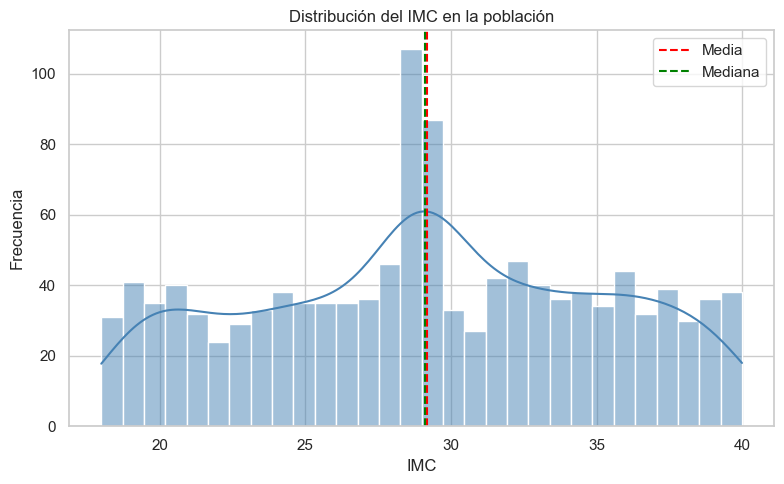

Media IMC: 29.18
Mediana IMC: 29.12
Conclusión: el IMC se distribuye de forma bastante uniforme entre 18 y 40, con media y mediana muy próximas, sin asimetría marcada. Buena parte de la población está en sobrepeso u obesidad.


In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df["imc"], bins=30, kde=True, color="steelblue")
plt.axvline(df["imc"].mean(), color="red", linestyle="--", label="Media")
plt.axvline(df["imc"].median(), color="green", linestyle="--", label="Mediana")
plt.title("Distribución del IMC en la población")
plt.xlabel("IMC")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()
 
print("Media IMC:", round(df["imc"].mean(), 2))
print("Mediana IMC:", round(df["imc"].median(), 2))
print("Conclusión: el IMC se distribuye de forma bastante uniforme entre 18 y 40, con media y mediana muy próximas, sin asimetría marcada. Buena parte de la población está en sobrepeso u obesidad.")

# Se aplicó imputación por mediana agrupada por rango de edad, pero al no existir correlación relevante entre edad e IMC en este dataset, el pico artificial se redujo pero no desapareció por completo.

In [44]:
# Pregunta 2: ¿Cómo varía la presión arterial según el nivel de actividad física?

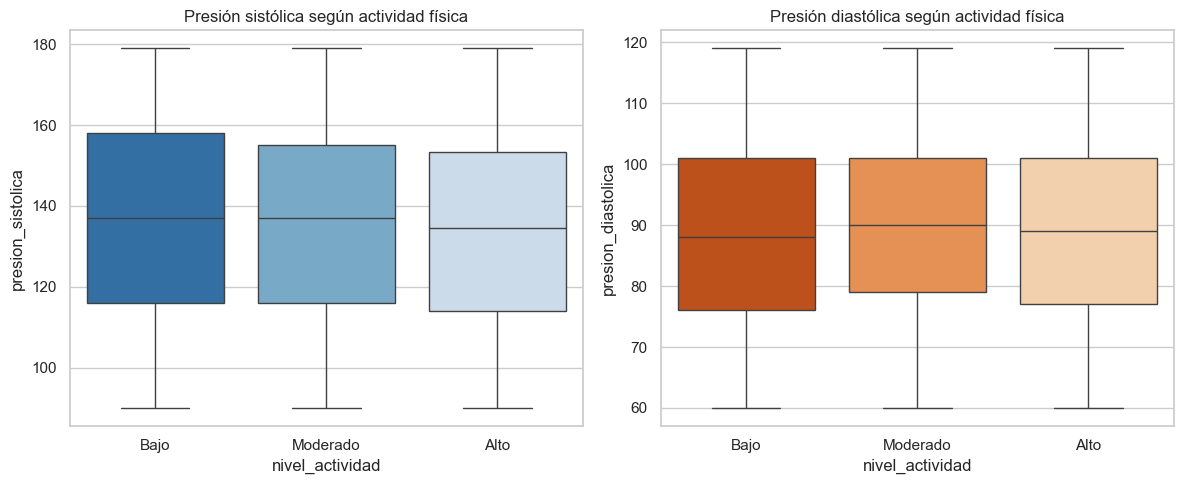

                 presion_sistolica  presion_diastolica
nivel_actividad                                       
Alto                         134.5                89.1
Bajo                         136.3                87.9
Moderado                     136.3                89.7
Conclusión: las medias son muy similares entre los tres grupos (sistólica 134-136 mmHg, diastólica 88-90 mmHg). No se observa una relación clara entre nivel de actividad física y presión arterial en este dataset.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
orden_actividad = ["Bajo", "Moderado", "Alto"]

sns.boxplot(data=df, x="nivel_actividad", y="presion_sistolica",
            order=orden_actividad, hue="nivel_actividad", legend=False,
            ax=axes[0], palette="Blues")
axes[0].set_title("Presión sistólica según actividad física")

sns.boxplot(data=df, x="nivel_actividad", y="presion_diastolica",
            order=orden_actividad, hue="nivel_actividad", legend=False,
            ax=axes[1], palette="Oranges")
axes[1].set_title("Presión diastólica según actividad física")

plt.tight_layout()
plt.show()

print(df.groupby("nivel_actividad", observed=True)
        [["presion_sistolica", "presion_diastolica"]].mean().round(1))
print("Conclusión: las medias son muy similares entre los tres grupos (sistólica 134-136 mmHg, diastólica 88-90 mmHg). No se observa una relación clara entre nivel de actividad física y presión arterial en este dataset.")

In [46]:
# Pregunta 3: ¿Existen diferencias en el número de pasos diarios entre fumadores y no fumadores?

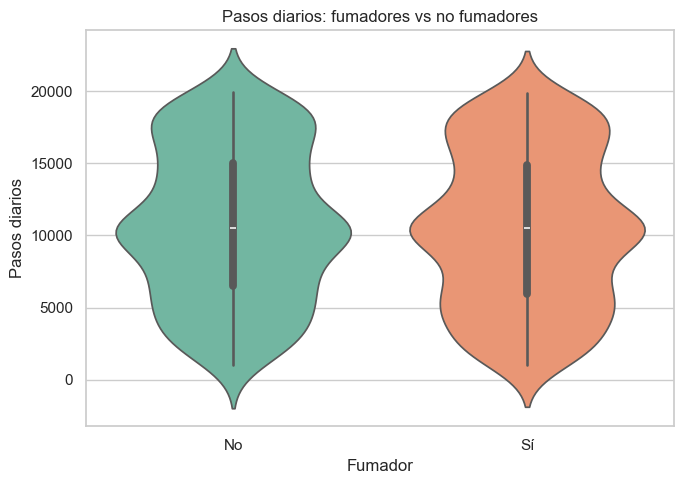

                 mean   median
fumador                       
No       10744.380309  10493.0
Sí       10425.727273  10493.0
Conclusión: la media de pasos es similar entre ambos grupos (10.744 no fumadores vs 10.426 fumadores).La coincidencia exacta de la mediana (10493.0) en ambos grupos es un artefacto de la imputación. Este valor corresponde a la mediana de pasos_diarios de uno de los niveles de actividad física,y se repite 53 veces en el dataset tras imputar los nulos por grupo, repartiéndose de forma similar entre fumadores y no fumadores. No indica necesariamente que ambos grupos caminen lo mismo en la realidad.


In [47]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="fumador", y="pasos_diarios",
                hue="fumador", legend=False, palette="Set2")
plt.title("Pasos diarios: fumadores vs no fumadores")
plt.xlabel("Fumador")
plt.ylabel("Pasos diarios")
plt.tight_layout()
plt.show()

print(df.groupby("fumador", observed=True)["pasos_diarios"].agg(["mean", "median"]))
print("Conclusión: la media de pasos es similar entre ambos grupos (10.744 no fumadores vs 10.426 fumadores).La coincidencia exacta de la mediana (10493.0) en ambos grupos es un artefacto de la imputación. Este valor corresponde a la mediana de pasos_diarios de uno de los niveles de actividad física,y se repite 53 veces en el dataset tras imputar los nulos por grupo, repartiéndose de forma similar entre fumadores y no fumadores. No indica necesariamente que ambos grupos caminen lo mismo en la realidad.")

In [48]:
# Pregunta 4: ¿Cómo se relaciona el número de horas de sueño con la satisfacción con la vida?

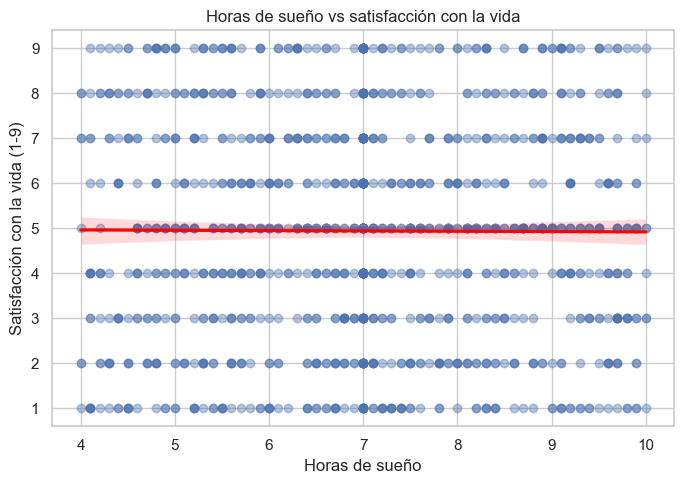

Correlación horas_sueno vs satisfaccion_vida: -0.005
Conclusión: la correlación es prácticamente 0 (-0.005). No existe relación lineal entre las horas de sueño y la satisfacción con la vida en este dataset.


In [49]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="horas_sueno", y="satisfaccion_vida",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Horas de sueño vs satisfacción con la vida")
plt.xlabel("Horas de sueño")
plt.ylabel("Satisfacción con la vida (1-9)")
plt.tight_layout()
plt.show()

correlacion = df["horas_sueno"].corr(df["satisfaccion_vida"])
print("Correlación horas_sueno vs satisfaccion_vida:", round(correlacion, 3))
print("Conclusión: la correlación es prácticamente 0 (-0.005). No existe relación lineal entre las horas de sueño y la satisfacción con la vida en este dataset.")

In [50]:
# Pregunta extra. Distribución de personas por categoría de IMC

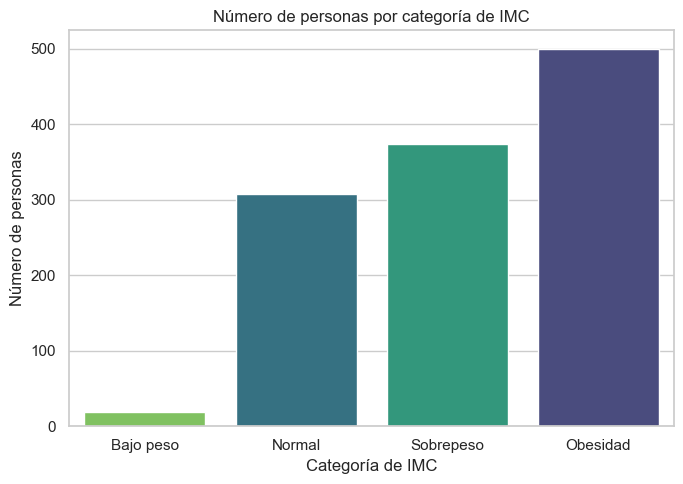

In [51]:
def clasificar_imc(valor):
    if valor < 18.5:
        return "Bajo peso"
    elif valor < 25:
        return "Normal"
    elif valor < 30:
        return "Sobrepeso"
    else:
        return "Obesidad"

df["categoria_imc"] = df["imc"].apply(clasificar_imc)
orden_imc = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="categoria_imc", order=orden_imc,
              hue="categoria_imc", legend=False, palette="viridis")
plt.title("Número de personas por categoría de IMC")
plt.xlabel("Categoría de IMC")
plt.ylabel("Número de personas")
plt.tight_layout()
plt.show()

In [52]:
# Pregunta extra. Matriz de correlación entre variables numéricas

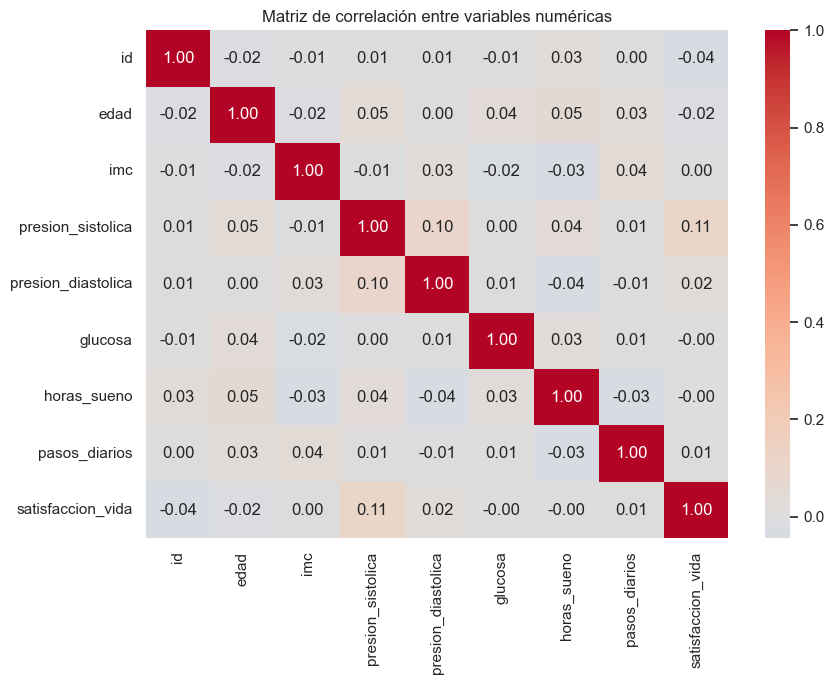

In [53]:
plt.figure(figsize=(9, 7))
num_cols = df.select_dtypes(include="number").columns.tolist()
matriz_corr = df[num_cols].corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()